In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


In [26]:
url = 'https://raw.githubusercontent.com/spamella04/Restaurant_and_Market_Health_Inspections/refs/heads/main/Restaurant_and_Market_Health_Inspections%20(1).csv'
data = pd.read_csv(url)

In [3]:
data.shape

(67573, 20)

In [59]:
data.head()

,serial_number,activity_date,facility_name,score,grade,service_code,service_description,employee_id,facility_address,facility_city,facility_id,facility_state,facility_zip,owner_id,owner_name,pe_description,program_element_pe,program_name,program_status,record_id
0,DAJ00E07B,12/29/2017 12:00:00 AM,HABITAT COFFEE SHOP,95,A,1,ROUTINE INSPECTION,EE0000923,3708 N EAGLE ROCK BLVD,LOS ANGELES,FA0170465,CA,90065,OW0178123,GLASSELL COFFEE SHOP LLC,RESTAURANT (0-30) SEATS MODERATE RISK,1631,HABITAT COFFEE SHOP,ACTIVE,PR0160774
1,DAQOKRFZB,12/29/2017 12:00:00 AM,REILLY'S,92,A,1,ROUTINE INSPECTION,EE0000633,100 WORLD WAY # 120,LOS ANGELES,FA0244690,CA,90045,OW0208441,"AREAS SKYVIEW LAX JV, LLC",RESTAURANT (0-30) SEATS MODERATE RISK,1631,REILLY'S,ACTIVE,PR0193026
2,DASJI4LUR,12/29/2017 12:00:00 AM,STREET CHURROS,93,A,1,ROUTINE INSPECTION,EE0000835,6801 HOLLYWOOD BLVD # 253,LOS ANGELES,FA0224109,CA,90028,OW0228670,"STREETCHURROS, INC",RESTAURANT (0-30) SEATS LOW RISK,1630,STREET CHURROS,ACTIVE,PR0179282
3,DA40LU5AT,12/29/2017 12:00:00 AM,TRINITI ECHO PARK,94,A,1,ROUTINE INSPECTION,EE0000923,1814 W SUNSET BLVD,LOS ANGELES,FA0252528,CA,90026-3227,OW0246287,AMERICAN HOSPITALITY,RESTAURANT (0-30) SEATS MODERATE RISK,1631,TRINITI ECHO PARK,ACTIVE,PR0201836
4,DAXV2RMYC,12/29/2017 12:00:00 AM,POLLEN,94,A,1,ROUTINE INSPECTION,EE0000923,2100 ECHO PARK AVE,LOS ANGELES,FA0252789,CA,90026,OW0246479,"POLLEN AND PASTRY , LLC",RESTAURANT (0-30) SEATS MODERATE RISK,1631,POLLEN,ACTIVE,PR0202148


In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67573 entries, 0 to 67572
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   serial_number        67573 non-null  object
 1   activity_date        67573 non-null  object
 2   facility_name        67573 non-null  object
 3   score                67573 non-null  int64 
 4   grade                67570 non-null  object
 5   service_code         67573 non-null  int64 
 6   service_description  67573 non-null  object
 7   employee_id          67573 non-null  object
 8   facility_address     67573 non-null  object
 9   facility_city        67573 non-null  object
 10  facility_id          67573 non-null  object
 11  facility_state       67573 non-null  object
 12  facility_zip         67573 non-null  object
 13  owner_id             67573 non-null  object
 14  owner_name           67573 non-null  object
 15  pe_description       67573 non-null  object
 16  prog

In [43]:
data.duplicated().sum()

0

In [42]:
data.isnull().sum()

serial_number          0
facility_name          0
score                  0
grade                  0
service_code           0
service_description    0
employee_id            0
facility_address       0
facility_city          0
facility_id            0
facility_state         0
facility_zip           0
owner_id               0
owner_name             0
pe_description         0
program_element_pe     0
program_name           0
program_status         0
record_id              0
year                   0
month                  0
day                    0
category               0
size                   0
riskLevel              0
dtype: int64

In [62]:
min_max_scores = data.groupby('grade')['score'].agg(['min', 'max']).reset_index()

# Mostrar el resultado
print(min_max_scores)

  grade  min  max
0         65   65
1     A   90  100
2     B   80   89
3     C   64   79


In [38]:
#Imprimiendo los registros donde el grade es null
print(data[data['grade'].isnull()])

Empty DataFrame
Columns: [serial_number, facility_name, score, grade, service_code, service_description, employee_id, facility_address, facility_city, facility_id, facility_state, facility_zip, owner_id, owner_name, pe_description, program_element_pe, program_name, program_status, record_id, year, month, day, category, size, riskLevel]
Index: []

[0 rows x 25 columns]


In [40]:
print(data[data['program_name'].isnull()])

      serial_number                facility_name  score grade  service_code  \
28707     DAUJTVCBM               YAKINIKU GRILL     94     A             1   
29010     DAXKKNV5S               JUICE CRAFTERS     95     A             1   
29382     DAC620KZG                      PHORAGE     93     A             1   
29383     DAD00OX8E                C JANG MARKET     96     A             1   
29398     DAVHQETCM             7-ELEVEN #39646A     96     A             1   
29425     DAQYKTQF7                    THE JUICE     94     A             1   
30343     DAPDOPWJN      TAQUERIA LOS 3 CARNALES     90     A             1   
30400     DAT1RRMV7       SPROUTS FARMERS MARKET     94     A             1   
30634     DATYBZXLM                          538    100     A             1   
31270     DAPGIUWDE                      33 TAPS     90     A             1   
31503     DAPIOSLKL             GOODGIRL THE DOG     92     A             1   
31672     DAJIUOWTF      CARNICERIA LA OAXAQUENA    

In [41]:
#Eliminandos los registros donde program_name es null
data = data.dropna(subset=['program_name'])

In [37]:
#Remplazando con el valor de 'C' los valores nulos de la columna grade
data['grade'].fillna('C', inplace=True)

C:\Users\synth\AppData\Local\Temp\ipykernel_28468\2571210395.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['grade'].fillna('C', inplace=True)


In [27]:
#convertir la columna fecha a date
data['activity_date'] = pd.to_datetime(data['activity_date'], errors='coerce').dt.date

C:\Users\synth\AppData\Local\Temp\ipykernel_28468\4063852609.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['activity_date'] = pd.to_datetime(data['activity_date'], errors='coerce').dt.date


In [ ]:
#Creacion de nuevas columnas: year, month y day



In [28]:
data['activity_date'] = pd.to_datetime(data['activity_date'], errors='coerce')
data['year'] = data['activity_date'].dt.year
data['month'] = data['activity_date'].dt.month
data['day'] = data['activity_date'].dt.day

In [29]:
#Eliminado columna activity_date
data.drop('activity_date', axis=1, inplace=True)

In [ ]:
#Creacion de nuevas columnas: PE DESCRIPTION, categoriza los establecimientos según su tipo, tamaño y nivel de riesgo. "FOOD MKT RETAIL (1-1,999 SF) LOW RISK".
#category, size, riskLevel


In [30]:
# Función para separar la información
def categorize_description(desc):
    # Valores predeterminados
    category = "Sin Información"
    size = "Desconocido"
    risk = "Desconocido"

    # Formato estándar
    standard_format = re.match(r'(.+?) \((.*?)\)( SEATS)?\s*(.+)', desc)
    if standard_format:
        category = standard_format.group(1).strip()
        size = standard_format.group(2).strip() + (" SEATS" if standard_format.group(3) else "")
        risk = standard_format.group(4).strip()
    else:
        # Formatos no estándar
        if "CATERER" in desc:
            category = "CATERER"
            size_match = re.search(r'\((.*?)\)', desc)
            if size_match:
                size = size_match.group(1)
        elif "FOOD MARKET" in desc:
            category = "FOOD MARKET"
        elif "FOOD PROCESSING" in desc:
            category = "FOOD PROCESSING"
            size_match = re.search(r'\((.*?)\)', desc)
            if size_match:
                size = size_match.group(1)
        elif "FOOD WAREHOUSE" in desc:
            category = "FOOD WAREHOUSE"
            size_match = re.search(r'\((.*?)\)', desc)
            if size_match:
                size = size_match.group(1)
        elif "SENIOR FEEDING SITE" in desc:
            category = "SENIOR FEEDING SITE"
        elif "PRIVATE SCHOOL" in desc:
            category = "PRIVATE SCHOOL"
        elif "WHOLESALE FOOD COMPLEX" in desc:
            category = "WHOLESALE FOOD COMPLEX"
    
    return pd.Series([category, size, risk])

In [31]:
# Aplicar la función al DataFrame
data[['category', 'size', 'riskLevel']] = data['pe_description'].apply(categorize_description)

In [34]:
#Eliminando registros donde riskLevel es Desconocido
data = data[data['riskLevel'] != 'Desconocido']

In [35]:
data = data[data['riskLevel'] != 'SQ. FT.']

In [44]:
data.head()

,serial_number,facility_name,score,grade,service_code,service_description,employee_id,facility_address,facility_city,facility_id,...,program_element_pe,program_name,program_status,record_id,year,month,day,category,size,riskLevel
0,DAJ00E07B,HABITAT COFFEE SHOP,95,A,1,ROUTINE INSPECTION,EE0000923,3708 N EAGLE ROCK BLVD,LOS ANGELES,FA0170465,...,1631,HABITAT COFFEE SHOP,ACTIVE,PR0160774,2017,12,29,RESTAURANT,0-30 SEATS,MODERATE RISK
1,DAQOKRFZB,REILLY'S,92,A,1,ROUTINE INSPECTION,EE0000633,100 WORLD WAY # 120,LOS ANGELES,FA0244690,...,1631,REILLY'S,ACTIVE,PR0193026,2017,12,29,RESTAURANT,0-30 SEATS,MODERATE RISK
2,DASJI4LUR,STREET CHURROS,93,A,1,ROUTINE INSPECTION,EE0000835,6801 HOLLYWOOD BLVD # 253,LOS ANGELES,FA0224109,...,1630,STREET CHURROS,ACTIVE,PR0179282,2017,12,29,RESTAURANT,0-30 SEATS,LOW RISK
3,DA40LU5AT,TRINITI ECHO PARK,94,A,1,ROUTINE INSPECTION,EE0000923,1814 W SUNSET BLVD,LOS ANGELES,FA0252528,...,1631,TRINITI ECHO PARK,ACTIVE,PR0201836,2017,12,29,RESTAURANT,0-30 SEATS,MODERATE RISK
4,DAXV2RMYC,POLLEN,94,A,1,ROUTINE INSPECTION,EE0000923,2100 ECHO PARK AVE,LOS ANGELES,FA0252789,...,1631,POLLEN,ACTIVE,PR0202148,2017,12,29,RESTAURANT,0-30 SEATS,MODERATE RISK


In [52]:
#Eliminando registros con especificos serial_number
data = data[data['serial_number'] != 'DAVTNZVG3']
data = data[data['serial_number'] != 'DADU3VZ4L']
data = data[data['serial_number'] != 'DAGNSISLK']
data = data[data['serial_number'] != 'DAOJO74T3']


In [51]:
data.isnull().sum()

serial_number          0
facility_name          0
score                  0
grade                  0
service_code           0
service_description    0
employee_id            0
facility_address       0
facility_city          0
facility_id            0
facility_state         0
facility_zip           0
owner_id               0
owner_name             0
pe_description         0
program_element_pe     0
program_name           0
program_status         0
record_id              0
year                   0
month                  0
day                    0
category               0
size                   0
riskLevel              0
dtype: int64

In [73]:
#Eliminando columna pe_description
data.drop('pe_description', axis=1, inplace=True)

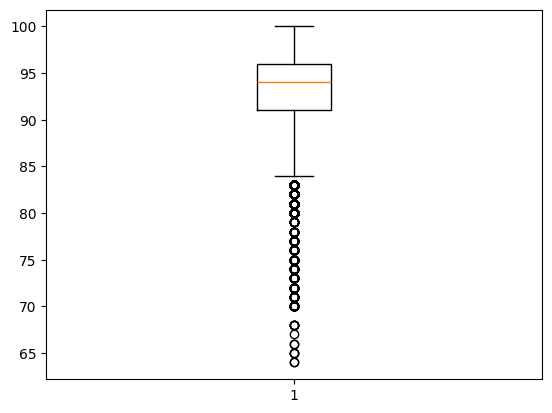

In [17]:
#Deteccion de outliers en la columna score
plt.boxplot(data['score'])
plt.show()

In [18]:
#Columnas a utilizarenel análisis

In [53]:
columns = ['serial_number','year','month','day','facility_id','facility_name', 'facility_zip','score','grade','service_description','category','size','riskLevel','owner_id','owner_name',]

In [54]:
#nuevo dataframe con las columnas seleccionadas
clean_data = data[columns]


In [55]:
clean_data.shape

(67519, 15)

In [56]:
#Guardando nuevo dataframe en un archivo csv
clean_data.to_csv('datasetLimpio.csv', index=False)